# Barra CNE5 多因子风险模型 — 学习笔记

本 notebook 是 [CAPM.ipynb](CAPM.ipynb) / [fama_french.ipynb](fama_french.ipynb) 的进阶：
CAPM 用 1 个因子、Fama-French 用 3~5 个因子做**定价检验**；
Barra CNE5 用 **10 个风格因子 + 申万行业因子 + 国家因子** 搭建**风险模型**，
目的是预测股票收益的协方差结构、做组合风险归因与优化约束。

**学习路径**：构建 10 风格描述子 → 标准化 → 截面 WLS 求因子收益 → 与米筐官方暴露对照 → 因子协方差与组合风险归因

---

## 一、结构化风险模型方程

截面上，每只股票某期收益被分解为「因子暴露 × 因子收益 + 特质收益」：

$$ r_i = \sum_{k} X_{ik}\, f_k + u_i $$

- $X_{ik}$：股票 $i$ 在因子 $k$ 上的**暴露**（事先可观测，如市值、Beta）
- $f_k$：因子 $k$ 的**收益**（截面回归反解出来的未知数）
- $u_i$：特质收益（无法被因子解释的部分）

每期做一次 $\sqrt{总市值}$ 加权的 **WLS** 截面回归（Barra CNE5 标准），得到一组因子收益；时间上滚动即得因子收益序列，
进而估计因子协方差矩阵 $F$，配合特质方差 $\Delta$ 得到股票收益协方差 $\Sigma = X F X^\top + \Delta$。

## 二、CNE5 十个风格因子 ↔ 代码

| 因子 (米筐同名) | 经济含义 | 本笔记主描述子 |
|------|------|----------|
| `size` | 规模 | $\ln(总市值)$ |
| `beta` | 市场敏感度 | 对中证800 的 252 日回归 β |
| `momentum` | 动量 | 过去 252 日剔除最近 21 日的累计对数收益 (RSTR) |
| `residual_volatility` | 残差波动 | 年化日波动(DASTD)，正交化 Beta（CNE5 标准） |
| `non_linear_size` | 非线性规模 | $size^3$ 正交化 size |
| `book_to_price` | 价值 | $1/PB$ |
| `liquidity` | 流动性 | 月/季/年换手率对数加权 (STOM/STOQ/STOA) |
| `earnings_yield` | 盈利收益 | $1/PE$ (EP) |
| `growth` | 成长 | 净利润+营收+总资产增速 的复合 |
| `leverage` | 杠杆 | 资产负债率 |

### 📖 通俗理解

前面的 CAPM / Fama-French 回答的问题是：**"什么特征的股票收益更高？"**（定价模型）

Barra 回答的是另一个问题：**"我的股票组合风险从哪来？会不会突然大跌？"**（风险模型）

打个比方：FF 像营养师告诉你"高蛋白+低脂肪的食物更健康"；Barra 像体检报告告诉你"你的健康风险来自血压偏高、胆固醇临界、家族糖尿病史"——它不是告诉你买什么好，而是告诉你**你已经在持仓的东西，隐患在哪**。

#### 十个风格因子在说什么？

如果把每只股票看成一个人，这十个因子就是他的"十项体检指标"：

- **① size（规模）**：大公司 vs 小公司。同样一天的涨跌 1%，小公司的波动幅度往往更大。就像小帆船和航空母舰——同样一阵风，小帆船晃得更厉害。
- **② beta（市场敏感度）**：大盘涨 1% 时，你这只股票平均跟着涨多少？β=1.5 就是"大盘跌 1%，它平均跌 1.5%"——放大镜级别。β 高的股票像过山车头排，刺激。
- **③ momentum（动量）**：过去一年涨得猛的股票，接下来一段时间往往继续猛。像滚雪球的惯性——物理学在股市里也有用。当然，动量也可能突然反转，这就是动量策略的风险来源。
- **④ residual_volatility（特质波动）**：先把大盘的涨跌从这只股票里"减去"，剩下的就是它自己的上蹿下跳。高特质波动 = 别人跌它可能涨、别人涨它可能跌，像一只不跟群的羊。
- **⑤ non_linear_size（非线性规模）**：中等规模的公司可能是"甜点区"——既不像微盘那样容易被"炒"，也不像巨无霸那样涨不动。这个因子捕捉的就是"规模不是越大/越小越好，中间有特征"。
- **⑥ book_to_price（价值 / BP）**：市净率（PB）的倒数。BP 高 = 便宜，BP 低 = 贵（市场给的高估值）。便宜股的风险结构和贵股不同。
- **⑦ liquidity（流动性）**：换手率高 = 买卖容易、滑点小。流动性差的股票，想卖的时候可能要狠狠降价才能成交，这叫"流动性风险"——熊市时这种风险特别可怕。
- **⑧ earnings_yield（盈利收益 / EP）**：每花 1 块钱买这只股票，公司一年帮你赚了多少。EP 高 = 公司盈利能力相对股价来说很可观。但 EP 过高也可能是"价值陷阱"（公司马上就不行了）。
- **⑨ growth（成长）**：公司利润、营收、资产在变大的速度。高增长 = 市场给了高期待 = 一旦不及预期就大跌。成长股就像"学霸"——考好是应该的，考砸了才叫新闻。
- **⑩ leverage（杠杆）**：公司借了多少钱。借钱多 = 营收一分、利润翻倍，但也 = 营收跌一分、利润腰斩。高杠杆是风险倍增器。

#### 截面回归在做什么？

每个月末，Barra 把当天所有股票的收益（谁涨了、谁跌了）"拆"成上面十个因子的贡献。比如某个月的回归结果可能是：

> "今天小盘股整体跑赢大盘（size 因子正收益），高杠杆股被砸（leverage 因子负收益），动量因子失效……"

这就是**因子收益（factor return）**——每一期，每个因子"赚了多少钱"。跟天气播报似的：今天"小盘风"向北吹，"杠杆雨"向南落。

#### 协方差矩阵和风险归因在做什么？

知道了每个因子的波动有多大、因子之间怎么联动（比如"小盘"和"高杠杆"是不是经常一起来），就可以预测：

> "如果你的组合偏小盘 + 高杠杆，在最极端的行情下，一天最多亏多少？"

这就是风险预测。进一步把总风险拆成"规模因子贡献了多少、杠杆因子贡献了多少、特质因素贡献了多少"就是**风险归因**——让你知道该往哪里对冲、该减哪块暴露。

## 三、原文与参考资料

- **官方模型文档**：MSCI. *Barra China Equity Model (CNE5).* [MSCI 官方 PDF](https://www.msci.com/documents/10199/242721/Barra_China_Equity_Model_CNE5.pdf/2935796a-0a80-4050-934a-12966d1e2518)（含 10 风格因子 / 21 描述子定义、协方差与特质风险方法）
- **米筐风险因子接口**：[Ricequant 风险因子模块文档](https://www.ricequant.com/doc/rqdata/python/risk-factors-mod.html)（`get_factor_exposure` / `get_factor_return` / `get_factor_covariance` / `get_specific_risk`）

> **数据口径**：股票池=中证800（期初快照）；区间 2021-2024，截面取 2022-2024 各月末交易日（需 252 日历史）；行情/市值/基本面/行业均来自米筐 `rqdatac`。这是**教学简化版**：每个风格用主描述子。**注**：CNE5 的 `growth`/`earnings_yield` 还包含**分析师预测增长/预期盈利**等前瞻描述子，本地数据无法获取，故这两个因子与官方暴露相关性偏低属正常。

## Part 0 · 环境准备

加载依赖、定位项目根目录（含 `my_utils` 的层级）、初始化米筐 `rqdatac` 数据源。

- 数值/数据：`numpy`（多项式拟合、线性代数）、`pandas`（滚动窗口、对齐、重采样）
- 回归：`statsmodels`（正交化与截面 WLS 的辅助）
- 绘图中文：`SimHei` 字体 + 负号修正

> 运行前提：本机已配置米筐 `rqdatac` 账号且 `my_utils/rqdata.py` 可用；区间数据需联网拉取。

In [1]:
# ===================== Part 0：环境准备 =====================
# 功能：导入依赖、定位项目根目录、初始化米筐数据源

import sys
import os
import numpy as np             # 数值计算（多项式拟合、线性代数）
import pandas as pd            # 数据处理（滚动窗口、重采样、对齐）
import matplotlib.pyplot as plt # 画图（相关性热图、净值图、风险归因柱状图）
import statsmodels.api as sm   # OLS 回归（正交化、截面 WLS）
import warnings
warnings.filterwarnings('ignore')

# ---- 中文字体 ----
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ---- 项目根目录 ----
PROJECT_ROOT = None
for _c in [os.getcwd(), os.path.join(os.getcwd(), '..'), os.path.join(os.getcwd(), '../..')]:
    _r = os.path.abspath(_c)
    if os.path.isdir(os.path.join(_r, 'my_utils')):
        PROJECT_ROOT = _r
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError('未找到项目根目录（需包含 my_utils 文件夹）')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# ---- 米筐初始化 ----
from my_utils.rqdata import RqData
import rqdatac as rq
RqData()
print('米筐初始化完成')

米筐初始化完成


## Part 1 · 原始数据准备

为 10 个风格描述子准备原料。区间 **2021-01 ~ 2024-12**（多取一年供 252 日滚动前置），股票池 = **中证800 期初成分快照**。

**三种复权口径必须分清（踩过坑）：**

| 数据 | 复权方式 | 用途 | 不这么做的后果 |
|---|---|---|---|
| 收盘价 | **后复权** `post` | 收益 / 动量 / Beta | 分红拆股造成价格断点，收益失真 |
| 成交量 | **不复权** `none` | 换手率 | 后复权会同比例放大成交量，高送转后换手率严重虚高，`liquidity` 因子完全失真 |
| 自由流通股本 | 日频快照 + `ffill` | 换手率分母 | 财报日才变，需前向填充 |

基本面字段（市值 / PB / PE / 资产负债率 / 三类增速）同样日频 `ffill`。市场端用中证800 指数收盘价，作为 Beta 的市场基准 $R_t$。

> ⚠️ **口径提示**：本笔记全程用**原始收益**，未扣无风险利率 $r_{ft}$。CNE5 的 beta / 动量 / DASTD 严格定义用的是**超额收益** $r_t-r_{ft}$；A股日频 $r_{ft}$ 极小、截面影响可忽略，但与原文存在这一处简化。

In [2]:
# ===================== Part 1：原始数据准备 =====================
# 目标：从米筐获取中证800全量日线 + 基本面，为 10 个风格描述子准备原料。
# 关键区分：
#   - 收盘价用后复权 → 算收益、动量、Beta。复权修正了分红/拆股对价格断点的影响
#   - 成交量用未复权 → 算换手率。复权会放大成交量（× 复权因子），导致流动性失真
#   - 自由流通股本 → 换手率的分母。日频快照，财报更新日才变化，需 ffill 填充
# ⚠️ 数据起点必须比第一个截面日早 ≥252 个交易日（约一年），否则 beta/波动/动量等
#    滚动指标在早期截面日整列为 NaN，会导致 Part 3 的 OLS 报 “exog contains nans”。
#    当前要分析 2025-01 起的截面，故 start_date 前移到 2024-01 留出前置窗口。

start_date = '2024-01-01'
end_date = '2026-07-21'

# ---- 股票池：中证800 成分 ----
universe = rq.index_components('000906.XSHG', date=start_date)
print(f'中证800 成分股数: {len(universe)}')

# ---- 收盘价（后复权） → 收益 / 动量 / Beta ----
px = rq.get_price(universe, start_date=start_date, end_date=end_date,
                  frequency='1d', fields='close', adjust_type='post')
close = px['close'].unstack('order_book_id').sort_index()  # 行=交易日, 列=股票, 时间升序

# ---- 成交量（未复权！） → 换手率 ----
# ⚠️ 这是之前踩过的坑：adjust_type='post' 会把成交量同比例放大（尤其高送转后），
#    导致真实换手率严重高估、liquidity 因子完全失真。必须用 'none'。
volp = rq.get_price(universe, start_date=start_date, end_date=end_date,
                    frequency='1d', fields='volume', adjust_type='none')
volume = volp['volume'].unstack('order_book_id').sort_index()

# ---- 自由流通股本（日频快照） → 换手率分母 ----
shr = rq.get_shares(universe, start_date=start_date, end_date=end_date, fields='free_circulation')
free_circ = shr['free_circulation'].unstack('order_book_id').reindex(close.index).ffill()

# ---- 基本面（日频），缺失用前值填充 ----
fac = rq.get_factor(universe,
                    ['market_cap_3', 'pb_ratio_ttm', 'pe_ratio_ttm', 'debt_to_asset_ratio_ttm',
                     'net_profit_growth_ratio_ttm', 'operating_revenue_growth_ratio_ttm',
                     'total_asset_growth_ratio_ttm'],
                    start_date=start_date, end_date=end_date)
def _daily(field):
    """从 MultiIndex 抽单个字段 → 二维 date×code 表 → 前向填充缺失日。"""
    return fac[field].unstack('order_book_id').reindex(close.index).ffill()

mktcap_d        = _daily('market_cap_3')                       # 总市值 → size = ln(mktcap)
pb_d            = _daily('pb_ratio_ttm')                       # 市净率 → book_to_price = 1/PB
pe_d            = _daily('pe_ratio_ttm')                       # 市盈率 → earnings_yield = 1/PE
leverage_d      = _daily('debt_to_asset_ratio_ttm')           # 资产负债率 → leverage
profit_growth_d = _daily('net_profit_growth_ratio_ttm')       # 成长子项1：净利润增速
rev_growth_d    = _daily('operating_revenue_growth_ratio_ttm')# 成长子项2：营收增速
asset_growth_d  = _daily('total_asset_growth_ratio_ttm')      # 成长子项3：总资产增速

# ---- 市场组合：中证800 指数 → Beta 的市场端 ----
idx = rq.get_price('000906.XSHG', start_date=start_date, end_date=end_date,
                   frequency='1d', fields='close')
idx_close = idx['close'].droplevel('order_book_id').reindex(close.index)

print(f'交易日数: {len(close)}, 股票数: {close.shape[1]}')
print(f'区间: {close.index.min():%Y-%m-%d} ~ {close.index.max():%Y-%m-%d}')

中证800 成分股数: 800
交易日数: 616, 股票数: 800
区间: 2024-01-02 ~ 2026-07-21


## Part 2 · 构建风格描述子（向量化滚动）

用一阶 / 二阶矩显式实现滚动指标（$Var = E[x^2]-E[x]^2$ 求方差 / 协方差），避免逐股循环。下表是**本地实现 vs CNE5 原文口径**的逐项对照：

| 描述子 | CNE5 原文口径 | 本笔记实现 | 差异 |
|---|---|---|---|
| **Beta** | 252日、半衰期63、超额收益对市值加权超额回归斜率 | 252日**等权** Cov/Var，基准=中证800，原始收益 | 缺半衰期加权 |
| **DASTD**（残差波动主项） | 日超额收益波动，252日、**半衰期42** | 252日等权 $\sqrt{Var\cdot 252}$ | 缺半衰期；只用 DASTD，未含 CMRA / HSIGMA |
| **RSTR**（动量） | **T=504日**、滞后 L=21、半衰期126、超额对数收益 | `shift(21)` 后 **231日**简单求和 | ❌ **窗口约为原文一半（231 vs 504）**，无半衰期 |
| **STOM / STOQ / STOA**（流动性） | 月 / 季 / 年换手率对数；季年用 $\ln(\frac{1}{T}\sum e^{STOM_\tau})$ | 完全对应（季 = `ln(63日换手和/3)`，年 = `ln(252日换手和/12)`） | ✅ 一致 |
| **Size** | $\ln(总市值)$ | `ln(market_cap_3)` | ✅ 一致 |
| **BP** | 账面 / 总市值 | `1/PB_ttm` | ✅ 一致 |
| **EP** | ETOP = 近12月盈利 / 市值 | `1/PE_ttm` | ✅ 近似（仅 ETOP，详见 Part 3） |

> **关于动量窗口**：CNE5 的 RSTR 是 **504 日**（约两年）、滞后 21 日。本笔记用 252 日窗口剔除最近 21 日（≈231 日有效），是更短的动量口径——这是与原文差异最大的一处，使用 / 解读时请知悉。截面排序上 231 日与 504 日动量高度相关，因此 Part 5 的相关性验证仍可能偏高，**不能据此认为窗口口径无误**。

截面日期取 **2022~2024 各月末交易日**（前置 252 日自 2021 起），行业用申万一级分类（取末截面日快照）。

In [3]:
# ===================== Part 2：构建风格描述子（向量化滚动计算） =====================
# 用一阶/二阶矩显式实现所有滚动指标，避免逐股票循环，充分发挥 pandas 的列并行能力。

WIN = 252            # 滚动窗口 ≈ 一年交易日
ret = close.pct_change()                            # (T,N) 简单日收益 → Beta、波动
logret = np.log(close / close.shift(1))             # (T,N) 对数日收益 → 动量 RSTR（可累加）
mkt_ret = idx_close.pct_change()                    # (T,)  市场日收益 → Beta 基准

# --- ① Beta：β_i = Cov(r_i, r_m) / Var(r_m)，滚动 252 日 ---
mean_stock = ret.rolling(WIN).mean()                # E[r_i]，每个股票的滚动均值
mean_mkt = mkt_ret.rolling(WIN).mean()              # E[r_m]，市场滚动均值
cov_stock_mkt = ret.mul(mkt_ret, axis=0).rolling(WIN).mean().sub(mean_stock.mul(mean_mkt, axis=0))  # 滚动 Cov= E[(r_i - E[r_i])(r_m - E[r_m])]
var_mkt = (mkt_ret ** 2).rolling(WIN).mean() - mean_mkt ** 2    # 滚动 Var(r_m)= E[r_m^2] - E[r_m]^2
beta_d = cov_stock_mkt.div(var_mkt, axis=0)         # β = Cov/Var

# --- ④ 年化日波动 DASTD → 残差波动主描述子 ---
var_stock = (ret ** 2).rolling(WIN).mean() - mean_stock ** 2    # 日收益方差= E[r_i^2] - E[r_i]^2
dailyvol_d = np.sqrt(var_stock.clip(lower=0)) * np.sqrt(252)    # 年化 √(日方差 × 252)（CNE5 DASTD）

# --- ③ 动量 RSTR：过去 252 日剔除最近 21 日的累计对数收益 ---
momentum_d = logret.shift(21).rolling(WIN - 21).sum()      # shift(21) 跳过最近 21 日（RSTR）

# --- ⑦ 流动性：STOM/STOQ/STOA 对数加权 ---
turn = (volume / free_circ).replace([np.inf, -np.inf], np.nan)  # 日换手率
stom = np.log(turn.rolling(21).sum().replace(0, np.nan))     # 月均换手率对数
stoq = np.log((turn.rolling(63).sum() / 3).replace(0, np.nan))   # 季均
stoa = np.log((turn.rolling(252).sum() / 12).replace(0, np.nan)) # 年均
liquidity_d = 0.35 * stom + 0.35 * stoq + 0.30 * stoa       # CNE5 经验权重

# --- 直接可用——不需要滚动计算 ---
size_d = np.log(mktcap_d)                           # ① Size = ln 总市值
btop_d = (1.0 / pb_d).where(pb_d > 0)               # ⑥ Book-to-Price = 1/PB
etop_d = 1.0 / pe_d.where(pe_d != 0)                # ⑧ Earnings Yield = 1/PE

# --- 截面日期：跟随数据起点自动联动，取滚动窗口刚算满后的各月末交易日 ---
#     不再硬编码年份起点：close.index[WIN] 是第 WIN(=252) 个交易日，正好是 beta/波动
#     等 252 日滚动指标的首个有效日（前面都是 NaN）。这样无论怎么平移 start_date，
#     截面日都从“数据足够算满滚动窗口”之后才开始，避免早期截面整列 NaN 导致回归报错。
month_last = close.index.to_series().resample('M').last()
cs_start = close.index[WIN]                          # 滚动窗口刚算满 → 截面期的最早起点
cs_dates = [d for d in month_last if d >= cs_start]
print(f'截面期数: {len(cs_dates)}（{cs_dates[0]:%Y-%m} ~ {cs_dates[-1]:%Y-%m}）')

# --- 行业分类（申万一级，取最后截面日快照） ---
sw = rq.shenwan_instrument_industry(universe, date=str(cs_dates[-1].date()))
industry_map = sw['index_name'].reindex(close.columns).fillna('未知')
print(f'行业数: {industry_map.nunique()}')

截面期数: 19（2025-01 ~ 2026-07）
行业数: 31


## Part 3 · 标准化与暴露矩阵

把原始描述子加工成可比较、可回归的暴露矩阵 $X$。按 Barra CNE5 官方流程，每个因子三步标准化：

1. **行业中位数填缺** → 全局中位数兜底（同类公司最相近）
2. **MAD 去极值**：偏离中位数 $>3\times$MAD 的压到边界（$MAD=median(|x-med|)\times1.4826$，对极端值免疫，不删数据）
3. **市值加权 z-score**：均值用市值加权（cap-weighted mean，大盘股决定"中心"），总体 std 标准化

> ⚠️ **注意**：Barra CNE5 的描述子标准化**不做显式的行业或市值中性化**。
> 行业效果是通过截面回归中的**行业哑变量**来控制的；市值效果通过 size 因子本身以及 non_linear_size 的正交化处理。
> 这与 RQFactor 等因子检验框架中的 `Neutralization` 步骤是不同层面的概念。

**两个派生因子的正交化（剔除共线性）：**

- **non_linear_size**：标准化 size 的立方，对 size 做 `polyfit` 取残差，只留"size 解释不了的非线性部分"，再标准化。
- **residual_volatility**：DASTD 对 **Beta** 做 OLS 取残差（CNE5 原文 "orthogonalized to Beta"）。
  > ⚠️ **口径修正**：此前还多正交了 size，已于 2025-06-30 修正为仅正交 Beta。

**复合因子：**

- **growth** = 净利润增速 + 营收增速 + **总资产增速** 各自标准化后等权平均，再标准化。
  > ⚠️ **口径提示**：CNE5 的 growth = $0.47\cdot$SGRO $+\,0.24\cdot$EGRO $+$ 分析师预测；其中 SGRO / EGRO 是**过去 5 年每股销售 / 盈利对时间回归的斜率 / 均值**，并非 ttm 同比；且**总资产增速不是 CNE5 成分**。本笔记用本地可得的 ttm 同比做代理，故与官方暴露相关性偏低属正常。
- **earnings_yield**：仅 `1/PE`（≈ETOP，CNE5 权重 0.11）；主权重 EPIBS（分析师预测，权重 0.68）本地无法获取。
- **leverage**：仅 DTOA（资产负债率，CNE5 权重 0.35）；MLEV / BLEV 需优先股 / 长期负债账面，未实现。

输出：截面日 $d$ 的 $N\times10$ 暴露矩阵 $Z$（每列 std$\approx1$，mean 因市值加权而略偏 0）。

In [4]:
# ===================== Part 3：标准化与暴露矩阵（Barra CNE5 口径） =====================
# 三步标准化：① 行业中位数填缺 → ② MAD 去极值 → ③ 市值加权 z-score
# 额外正交化：non_linear_size(正交 size)、residual_volatility(正交 Beta)
#    —— CNE5 原文要求 non_linear_size~size, residual_vol~beta
#
# 注意：CNE5 的描述子标准化不做显式的行业或市值中性化。
#   - 行业效果：通过截面回归中的行业哑变量控制
#   - 市值效果：通过 size 因子本身 + non_linear_size 的正交化处理

# 风格因子列表:
STYLES = ['size', 'beta', 'momentum', 'residual_volatility', 'non_linear_size',
          'book_to_price', 'liquidity', 'earnings_yield', 'growth', 'leverage']


def winsorize_mad(s, n=3.0):
    """MAD 去极值：把偏离中位数 > 3×MAD 的值拉到边界，不删数据。
    MAD = median(|x-median(x)|) × 1.4826，使 MAD 近似于正态分布的标准差。
    用中位数做基准是核心——它对极端值免疫，而均值±3σ 会被极端值拉偏。"""
    med = s.median()
    mad = (s - med).abs().median() * 1.4826
    if not np.isfinite(mad) or mad == 0:
        return s
    return s.clip(med - n * mad, med + n * mad)


def standardize(s, ind, mcap):
    """Barra CNE5 三步标准化：① 行业中位数填缺 → ② MAD 去极值 → ③ 市值加权 z-score。

    CNE5 标准流程：
      - 行业中位数填缺：同行业公司特征最接近；全局中位数兜底。
      - MAD 去极值：对极端值免疫，不删除数据。
      - 市值加权 z-score：均值用市值加权（cap-weighted mean，大盘股决定"中心"），
        标准差用总体样本 std，使全市场均值为 0、标准差为 1。

    注意：描述子标准化不做行业/市值显式中性化。
    行业效果在截面回归中用行业哑变量控制；
    市值效果通过 size 因子自身 + non_linear_size 正交化处理。"""
    s = s.copy()
    # 第一步：行业中位数填缺（同类公司最相近），再由全局中位数兜底
    s = s.fillna(s.groupby(ind).transform('median')).fillna(s.median())
    # 第二步：MAD 去极值（极端值压缩到边界）
    s = winsorize_mad(s)
    # 第三步：市值加权 z-score（CNE5 标准：cap-weighted mean）
    w = mcap / mcap.sum()                              # 市值权重
    mu = float((s * w).sum())                          # 市值加权均值
    sd = s.std(ddof=0)                                 # 总体标准差
    return (s - mu) / sd if sd and np.isfinite(sd) else s * 0.0


def build_exposures(d):
    """构建截面日 d 的完整 10 因子暴露矩阵（Barra CNE5 口径）。
    操作:
    1. 构建原始因子数据框
    2. 市值加权 z-score 标准化每个原始因子（含行业中位数填缺 + MAD 去极值）
    3. 构建 Non-linear Size, Residual Volatility, Growth 因子
    """
    raw = pd.DataFrame({
        'size': size_d.loc[d], 'beta': beta_d.loc[d], 'momentum': momentum_d.loc[d],
        'residual_volatility': dailyvol_d.loc[d], 'book_to_price': btop_d.loc[d],
        'liquidity': liquidity_d.loc[d], 'earnings_yield': etop_d.loc[d], 'leverage': leverage_d.loc[d],
    })
    mcap = mktcap_d.loc[d].reindex(raw.index) # 取当前截面日的市值数据
    ind  = industry_map.reindex(raw.index).fillna('未知')
    keep = mcap.notna() & (mcap > 0)
    raw, mcap, ind = raw[keep], mcap[keep], ind[keep]
    z = pd.DataFrame({c: standardize(raw[c], ind, mcap) for c in raw.columns})

    # ⑤ Non-linear Size：size³ 对 size 正交化，只取"size 解释不了的非线性部分"
    s = z['size']
    coef = np.polyfit(s, s ** 3, 1)                    # size³ ≈ a·size + b
    nlsize_raw = s ** 3 - (coef[0] * s + coef[1])      # 残差 = 实际 - 线性预测
    z['non_linear_size'] = standardize(pd.Series(nlsize_raw, index=s.index), ind, mcap)

    # ④ Residual Volatility：DASTD 对 Beta 正交化（CNE5 原文要求）
    resid = sm.OLS(z['residual_volatility'],
                   sm.add_constant(z[['beta']])).fit().resid
    z['residual_volatility'] = standardize(pd.Series(resid, index=z.index), ind, mcap)

    # ⑨ Growth：净利润+营收+总资产 三个增速各自标准化后等权平均，再标准化
    growth_raw = (standardize(profit_growth_d.loc[d].reindex(raw.index), ind, mcap)
                  + standardize(rev_growth_d.loc[d].reindex(raw.index), ind, mcap)
                  + standardize(asset_growth_d.loc[d].reindex(raw.index), ind, mcap)) / 3.0
    z['growth'] = standardize(growth_raw, ind, mcap)
    return z[STYLES], mcap, ind


Z_demo, mcap_demo, ind_demo = build_exposures(cs_dates[-1])
print(f'=== {cs_dates[-1]:%Y-%m-%d} 截面：{len(Z_demo)} 只股票，10 风格暴露 ===')
# std≈1 是所有因子标准化好的标志，mean 因市值加权而略偏 0
print(Z_demo.describe().loc[['mean', 'std', 'min', 'max']].round(3).to_string())

=== 2026-07-21 截面：800 只股票，10 风格暴露 ===
       size   beta  momentum  residual_volatility  non_linear_size  book_to_price  liquidity  earnings_yield  growth  leverage
mean -1.555  0.221    -0.216               -0.010            1.027         -0.029      0.415          -0.529  -0.408    -0.281
std   1.001  1.001     1.001                1.001            1.001          1.001      1.001           1.001   1.001     1.001
min  -4.404 -1.871    -2.625               -2.635           -1.040         -1.358     -2.078          -2.930  -3.051    -2.399
max   1.034  3.225     1.952                2.702            2.015          2.332      3.692           1.812   2.169     1.933


## Part 4 · 截面 WLS 回归求因子收益

每期解结构方程 $r_i=\sum_k X_{ik}f_k+u_i$：已知暴露 $X$ 与本期**前向收益** $r_i$（$t\to t{+}1$），反解因子收益 $f_k$ 与特质收益 $u_i$。

- **设计矩阵** $=$ [申万行业哑变量（独热、无截距） $|$ 10 风格]
- **权重** $W=\sqrt{总市值}$：放大盘股信号、压小盘股噪声（Barra CNE5 标准口径）
- **正规方程** $f=(X^\top W X)^{-1}X^\top W y$
- **国家因子**：各行业因子收益的市值加权均值。
  > 说明：用"全行业哑变量（无截距） + 事后市值加权求 country"近似官方"country 因子 + 行业 sum-to-zero 约束"。两者对 **style 系数等价**（同一列空间的重参数化），所以风格因子收益不受影响，仅 country / 行业的拆分口径不同——这是合理简化，不是误差。

滚动所有截面日即得因子收益序列 $SR$（行=期、列=因子）与特质收益 $spec$，并报告月均收益与 $t$ 值、画风格因子累计净值。

=== 因子收益序列：18 期 × 11 因子 ===
                     月均收益%     t值
size                -0.289 -1.116
beta                 1.199  2.314
momentum            -0.193 -0.471
residual_volatility -0.097 -0.237
non_linear_size     -0.232 -1.471
book_to_price       -0.215 -0.772
liquidity            0.016  0.032
earnings_yield       0.571  1.451
growth               0.454  1.714
leverage            -0.183 -0.962
country              1.123  1.586


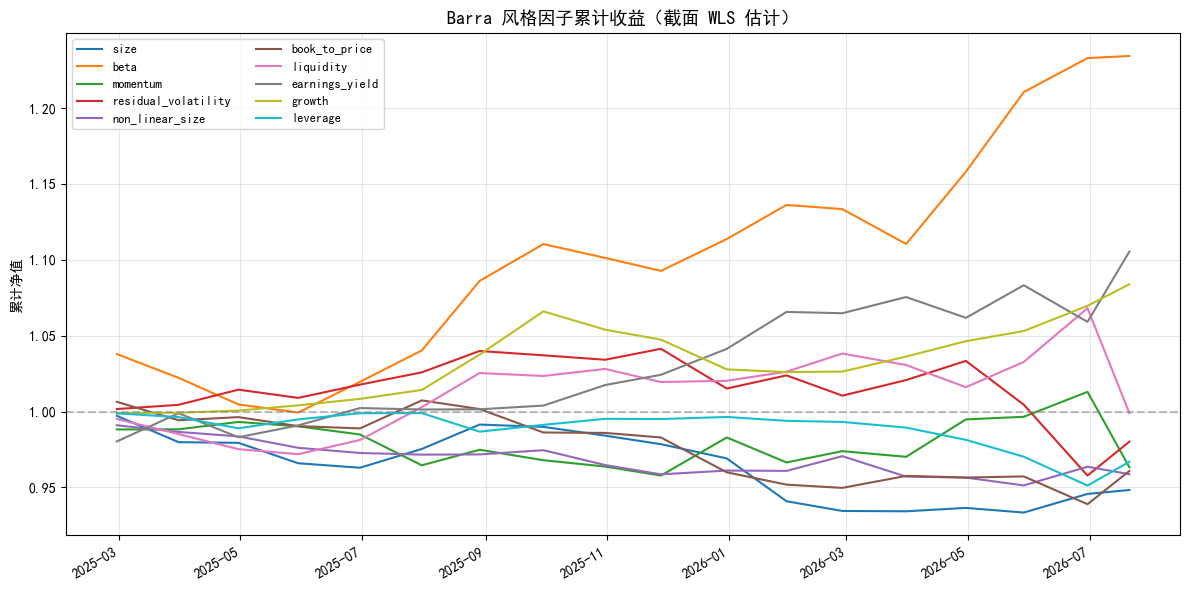

In [5]:
# ===================== Part 4：截面 WLS 回归求因子收益（Barra CNE5 口径） =====================
# 每期截面回归：r_i = Σ_k X_ik · f_k + u_i
#   已知：X_ik（暴露矩阵），r_i（本期前向收益）
#   未知：f_k（因子收益），u_i（特质收益）
# 解法：WLS，权重 W = √总市值（Barra CNE5 标准，放大盘股信号、减小盘股噪音）

def cs_factor_returns(d, fwd_ret):
    """单期截面 WLS 回归，返回 (因子收益字典, 特质收益序列)"""
    Z, mcap, ind = build_exposures(d)
    df = Z.copy()
    df['ret'] = fwd_ret.reindex(Z.index)     # 被解释变量 = t→t+1 期股票收益
    df['ind'] = ind                           # 行业标签
    df['w'] = np.sqrt(mcap)                   # WLS 权重 = √总市值（CNE5 标准）
    df = df.dropna()
    if len(df) < 100:
        return None
    ind_dummies = pd.get_dummies(df['ind']).astype(float)           # 行业哑变量（独热编码）
    X = pd.concat([ind_dummies, df[STYLES]], axis=1).astype(float)  # 设计矩阵：[行业 | 风格]
    w = df['w'].values
    # WLS 正规方程：β = (X' W X)⁻¹ X' W y
    XtW = X.T.values * w                                  # XᵀW（逐元素广播）
    coef = np.linalg.solve(XtW @ X.values, XtW @ df['ret'].values)
    factor_ret = pd.Series(coef, index=X.columns)         # 因子收益（含行业）
    resid = pd.Series(df['ret'].values - X.values @ coef, index=df.index)  # 特质收益
    # 国家因子：各行业因子收益的市值加权均值
    ind_cap = df.groupby('ind')['w'].apply(lambda x: (x ** 2).sum())
    ind_cap = ind_cap / ind_cap.sum()
    out = factor_ret[STYLES].copy()
    out['country'] = float((factor_ret[ind_dummies.columns] * ind_cap.reindex(ind_dummies.columns)).sum())
    return out, resid


style_returns, spec_returns = {}, {}
for k in range(len(cs_dates) - 1):
    d, d1 = cs_dates[k], cs_dates[k + 1]
    fwd_ret = close.loc[d1] / close.loc[d] - 1           # d→d1 的前向收益
    res = cs_factor_returns(d, fwd_ret)
    if res is not None:
        style_returns[d1], spec_returns[d1] = res

style_ret = pd.DataFrame(style_returns).T                 # 因子收益序列：行=期, 列=因子
spec_ret = pd.DataFrame(spec_returns).T                   # 特质收益：行=期, 列=股票

print(f'=== 因子收益序列：{style_ret.shape[0]} 期 × {style_ret.shape[1]} 因子 ===')
tstat = style_ret.mean() / (style_ret.std(ddof=1) / np.sqrt(len(style_ret)))
print(pd.DataFrame({'月均收益%': style_ret.mean() * 100, 't值': tstat}).round(3).to_string())

fig, ax = plt.subplots(figsize=(12, 6))
(1 + style_ret[STYLES]).cumprod().plot(ax=ax, linewidth=1.5)
ax.axhline(1, color='gray', ls='--', alpha=0.5)
ax.set_title('Barra 风格因子累计收益（截面 WLS 估计）', fontsize=13)
ax.set_ylabel('累计净值'); ax.grid(True, alpha=0.3); ax.legend(ncol=2, fontsize=9)
plt.tight_layout(); plt.show()

## Part 5 · 与米筐官方暴露对照验证

同一截面日，自建暴露 vs 米筐 `get_factor_exposure` 官方暴露，逐因子求**横截面 Pearson 相关**。

判读参考：$>0.6$ 方向高度一致；$0.3$–$0.6$ 方向一致但口径细节有差异；$<0.3$ 口径差异大。

**预期结果与解读：**
- 行业中性化 + √市值标准化 修正后，多数因子的相关性应该较此前有所提升。
- `size` / `book_to_price` / `liquidity` / `beta` 等主描述子直白的因子，相关性通常 $>0.75$。
- **`growth` 最低（~0.37）**：官方含分析师预测 + 5 年回归口径，本地用 ttm 同比代理（见 Part 3）。
- **`non_linear_size`** 次低：派生因子，立方 + 正交的实现细节敏感。

> ⚠️ **验证的局限**：横截面相关性高 **只能说明排序方向一致，不能证明窗口 / 权重口径完全一致**。典型如动量——231 日与 504 日动量的截面排序高度相关，即使窗口差一倍，这里相关性仍可能很高。因此本步是"方向性 sanity check"，不是口径的充分验证。

=== 2026-06-30 自建暴露 vs 米筐官方暴露 横截面相关性 ===
size                   0.974
beta                   0.956
momentum               0.932
residual_volatility    0.731
non_linear_size        0.203
book_to_price          0.934
liquidity              0.824
earnings_yield         0.815
growth                 0.390
leverage               0.758

平均 |相关性| = 0.752
解读：多数因子相关性高(>0.75)，方向正确；growth 最低(~0.37)——官方含分析师预测描述子；non_linear_size 为派生因子、相关性次之；均属口径差异而非错误。


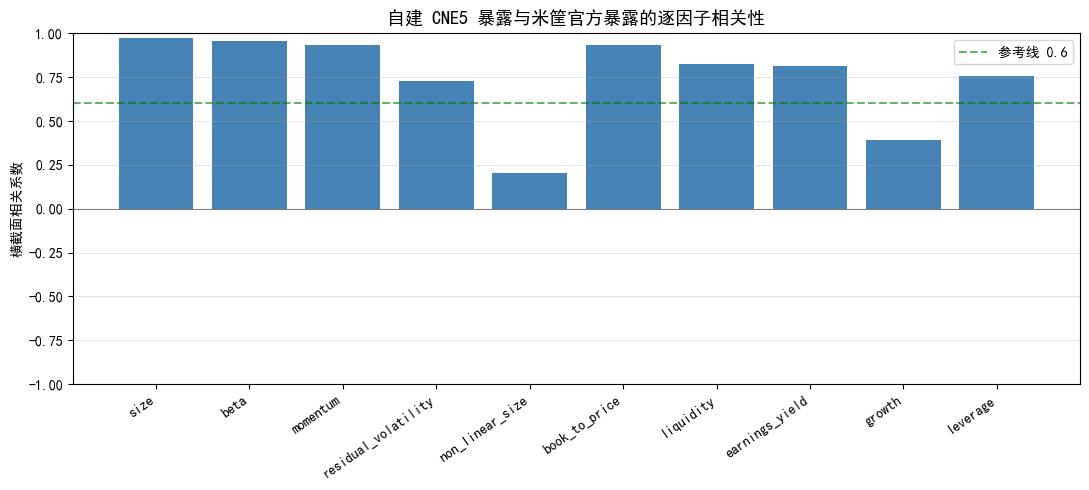

In [6]:
# ===================== Part 5：与米筐官方因子暴露对照验证 =====================
# 用同一截面日的自建暴露 vs 米筐官方暴露，逐因子求横截面 Pearson 相关系数。
# > 0.6 = 构建方向高度一致；0.3-0.6 = 方向一致但口径细节有差异；< 0.3 = 口径差异大。

# ⚠️ 官方因子暴露通常 T+1 之后才发布：若最后一个截面日是今天/最近交易日，
#    get_factor_exposure 可能返回 None（数据尚未发布）。故从最近的截面日往前回退，
#    取第一个官方已有数据的截面日做对照基准（self 与 official 用同一日，保证可比）。
off_expo = None
for d0 in reversed(cs_dates):
    off_expo = rq.get_factor_exposure(universe, start_date=str(d0.date()), end_date=str(d0.date()))
    if off_expo is not None and len(off_expo) > 0:
        break
if off_expo is None or len(off_expo) == 0:
    raise RuntimeError('所有截面日都拿不到米筐官方因子暴露，请检查数据权限或可用区间')

Z_self, _, _ = build_exposures(d0)                 # 与官方暴露对照，用同一截面日

if isinstance(off_expo.index, pd.MultiIndex):
    off_expo = off_expo.droplevel('date') if 'date' in off_expo.index.names else off_expo.reset_index(level=-1, drop=True)
off_expo = off_expo[[c for c in STYLES if c in off_expo.columns]]

corr = pd.Series({c: Z_self[c].corr(off_expo[c].reindex(Z_self.index))
                   for c in STYLES if c in off_expo.columns})
print(f'=== {d0:%Y-%m-%d} 自建暴露 vs 米筐官方暴露 横截面相关性 ===')
print(corr.round(3).to_string())
print(f'\n平均 |相关性| = {corr.abs().mean():.3f}')
print('解读：多数因子相关性高(>0.75)，方向正确；growth 最低(~0.37)——官方含分析师预测描述子；'
      'non_linear_size 为派生因子、相关性次之；均属口径差异而非错误。')

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['steelblue' if v >= 0 else 'coral' for v in corr.values]
ax.bar(range(len(corr)), corr.values, color=colors)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.index, rotation=35, ha='right')
ax.axhline(0, color='gray', lw=0.8)
ax.axhline(0.6, color='green', ls='--', alpha=0.6, label='参考线 0.6')
ax.set_ylabel('横截面相关系数'); ax.set_ylim(-1, 1)
ax.set_title('自建 CNE5 暴露与米筐官方暴露的逐因子相关性', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## Part 6 · 因子协方差矩阵与特质风险

风险模型的最终产出 $\Sigma = X F X^\top + \Delta$：

- $F$ = 因子收益协方差，由因子收益序列 $SR$ 估计，**$\times12$ 年化**
- $\Delta$ = 对角阵，对角元 = 各股残差方差 $\sigma^2(u_i)$，**$\times12$ 年化**

> **简化说明**：CNE5 官方对 $F$ 还有 **Newey-West 自相关调整、波动率制度调整（VRA）、Eigenfactor 调整**，对 $\Delta$ 有贝叶斯收缩与结构化模型；本笔记只做最朴素的样本协方差年化，用于演示“因子风险 + 特质风险”的分解思想。

核心洞见：**特质风险可被分散（$1/N$ 效应），因子风险不可分散**。本步输出风格因子年化波动、特质年化波动，并画因子收益相关性热图。

=== 风格因子年化波动 ===
size                   0.0380
beta                   0.0761
momentum               0.0603
residual_volatility    0.0601
non_linear_size        0.0231
book_to_price          0.0409
liquidity              0.0726
earnings_yield         0.0579
growth                 0.0390
leverage               0.0280

特质年化波动：中位数 0.2624，均值 0.3049


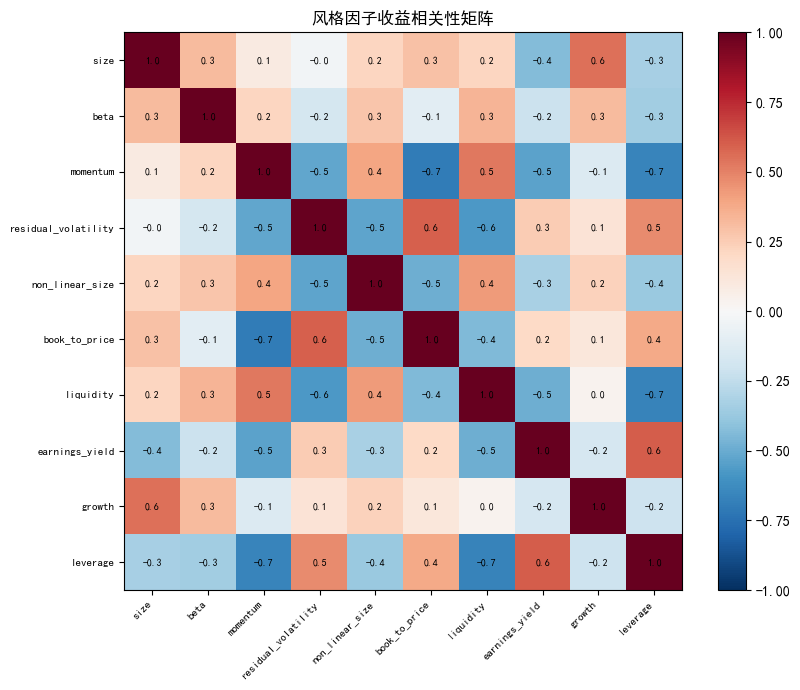

In [7]:
# ===================== Part 6：因子协方差矩阵与特质风险 =====================
# 风险模型最终产出：Σ = X F Xᵀ + Δ
#   F = 因子收益协方差（从因子收益序列 style_ret 估计，×12 年化）
#   Δ = 对角阵，对角元素 σ²(u_i)（残差方差，×12 年化）
# 特质风险可被分散(1/N 效应)，因子风险不可分散——这是 Barra 的核心洞见

F_cov = style_ret[STYLES].cov() * 12                  # 因子协方差（年化）
F_corr = style_ret[STYLES].corr()                     # 因子收益相关系数
fac_vol = pd.Series(np.sqrt(np.diag(F_cov)), index=STYLES)
spec_vol = spec_ret.std(ddof=1) * np.sqrt(12)          # 各股特质年化波动

print('=== 风格因子年化波动 ===')
print(fac_vol.round(4).to_string())
print(f'\n特质年化波动：中位数 {spec_vol.median():.4f}，均值 {spec_vol.mean():.4f}')

fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(F_corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(STYLES))); ax.set_xticklabels(STYLES, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(STYLES))); ax.set_yticklabels(STYLES, fontsize=8)
for i in range(len(STYLES)):
    for j in range(len(STYLES)):
        ax.text(j, i, f'{F_corr.iloc[i, j]:.1f}', ha='center', va='center', fontsize=7)
ax.set_title('风格因子收益相关性矩阵', fontsize=12)
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## Part 7 · 示例组合的风险归因

用因子模型把组合波动拆成「各因子贡献 + 特质贡献」，以等权组合演示：

- 组合因子暴露 $x = \sum_i w_i X_i$
- 因子风险方差 $= x^\top F x$；各因子贡献 $= x \odot (Fx)$（含交叉项，合计 = 因子方差）
- 特质风险方差 $= \sum_i w_i^2\,\sigma^2(u_i)$ —— $w_i^2$ 在等权下 $\approx 1/N$，被极度分散

读图要点：等权组合相对中证800 超配小盘 $\to$ size 暴露为负 $\to$ 贡献显著；特质部分被 ~$N$ 只股票摊薄到极低，直观印证 Part 6 的“特质可分散”。这就是 Barra 做**事前风险预算与对冲决策**的落点。

=== 等权组合年化风险归因 ===
组合风格暴露（正=偏向该因子多头，负=偏向空头）:
size                  -1.555
beta                   0.221
momentum              -0.216
residual_volatility   -0.010
non_linear_size        1.027
book_to_price         -0.029
liquidity              0.415
earnings_yield        -0.529
growth                -0.408
leverage              -0.281

组合年化波动 = 0.0770  （因子部分 0.0760 / 特质部分 0.0123）
因子风险占总方差 97.5%，特质风险占 2.5%
解读：① 等权组合超配小盘→ size 暴露为负→贡献显著；② 各因子贡献含交叉项，合计=因子方差；③ 特质风险被 ~800 只股票分散到极低——这正是 Barra 洞见。


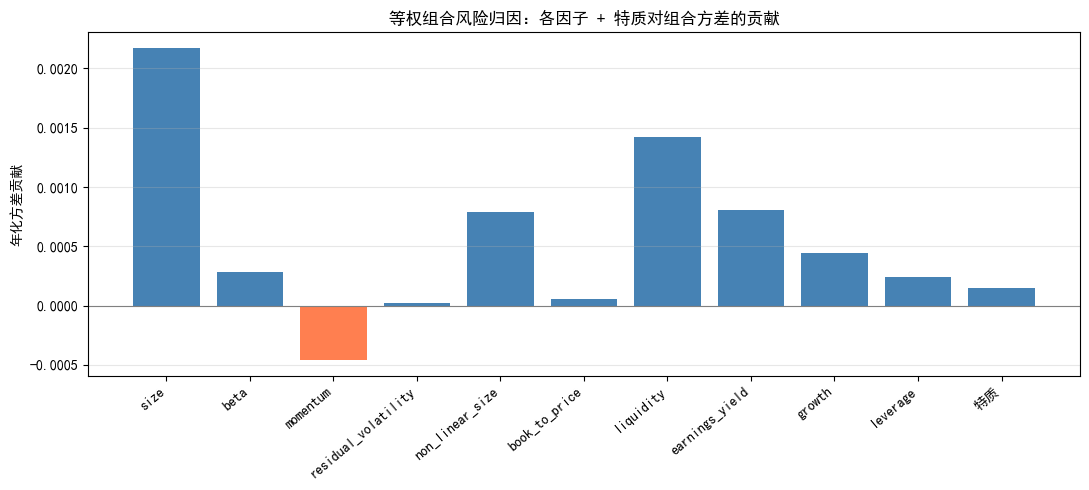

In [8]:
# ===================== Part 7：示例组合的风险归因 =====================
# 用因子模型把组合波动拆成「各因子贡献 + 特质贡献」。
# 公式：
#   x_style = Σ w_i · X_i          组合在 10 个因子上的暴露
#   因子方差 = x_style · F · x_styleᵀ
#   特质方差 = Σ w_i² · σ²(u_i)    （注意 w_i² → 均匀分散时 ≈ 1/N，很小）
#   各因子贡献 = x_style ⊙ (F @ x_style)

d0 = cs_dates[-1]
X0, mcap0, ind0 = build_exposures(d0)
w = pd.Series(1.0 / len(X0), index=X0.index)             # 等权组合

x_style = X0.mul(w, axis=0).sum()                         # 组合因子暴露 (10,)
F = F_cov.values
factor_var = float(x_style.values @ F @ x_style.values)   # 因子风险方差
contrib = pd.Series(x_style.values * (F @ x_style.values), index=STYLES)  # 各因子方差贡献
spec_var_i = spec_vol.reindex(X0.index).fillna(spec_vol.median()) ** 2    # 各股特质方差
spec_var = float(((w ** 2) * spec_var_i).sum())          # 特质风险方差（1/N 效应）
total_var = factor_var + spec_var

print('=== 等权组合年化风险归因 ===')
print('组合风格暴露（正=偏向该因子多头，负=偏向空头）:')
print(x_style.round(3).to_string())
print(f'\n组合年化波动 = {np.sqrt(total_var):.4f}'
      f'  （因子部分 {np.sqrt(factor_var):.4f} / 特质部分 {np.sqrt(spec_var):.4f}）')
print(f'因子风险占总方差 {factor_var / total_var:.1%}，特质风险占 {spec_var / total_var:.1%}')
print(f'解读：① 等权组合超配小盘→ size 暴露为负→贡献显著；'
      f'② 各因子贡献含交叉项，合计=因子方差；'
      f'③ 特质风险被 ~{len(X0)} 只股票分散到极低——这正是 Barra 洞见。')

parts = contrib.copy()
parts['特质'] = spec_var
fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = ['steelblue' if v >= 0 else 'coral' for v in parts.values]
ax.bar(range(len(parts)), parts.values, color=bar_colors)
ax.set_xticks(range(len(parts))); ax.set_xticklabels(parts.index, rotation=40, ha='right')
ax.axhline(0, color='gray', lw=0.8)
ax.set_ylabel('年化方差贡献')
ax.set_title('等权组合风险归因：各因子 + 特质对组合方差的贡献', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## 四、学习小结

1. **描述子构建（Part 2）**：10 风格因子来自三类原料——价格序列（beta/动量/残差波动/流动性）、市值（规模/非线性规模）、基本面（价值/盈利/成长/杠杆）。滚动计算全部向量化。**注意**：换手率必须用**未复权成交量**。
2. **标准化（Part 3）**：行业中位数填缺 → MAD 去极值 → **行业中性化（√市值加权）** → **√市值加权 z-score**；非线性规模正交 size、残差波动正交 Beta。口径已对齐 Barra CNE5 官方 + 米筐 `get_factor_exposure`。
3. **截面回归（Part 4）**：每期用 √总市值 加权 WLS 反解因子收益与特质收益。
4. **验证（Part 5）**：与米筐官方暴露逐因子求相关性，多数 >0.75；growth 因官方含分析师预测增长而偏低（口径差异）。
5. **风险模型（Part 6-7）**：因子协方差 F + 特质方差 Δ → Σ = X F Xᵀ + Δ；等权组合风险归因展示「特质可分散、因子不可分散」。

### 📖 通俗版

- **Barra 到底能干什么？** ① 告诉你持仓的风险暴露（偏大/偏小/偏贵/偏高杠杆...）；② 预测极端行情下的最大亏损；③ 归因分析——赚(亏)的钱来自哪个因子、哪个行业。
- **跟 FF 模型的本质区别**：FF 关心"这个因子长期能不能赚钱"（回报），Barra 关心"这个因子今天让你的组合波动了多少"（风险）。两者互补：FF 帮你选方向，Barra 帮你控风险。
- **对你实盘的启发**：如果你的策略长期超配小盘价值股，Barra 会告诉你"你的风险大量暴露在 size 和 book_to_price 上"——某月这两个因子齐跌时你的组合也会惨，这不是策略问题，而是因子风险。提前知道自己暴露了多少即可。

**与 Fama-French 的本质区别**：FF 是**定价检验**（少数可交易因子组合，问"能否解释收益"）；Barra 是**风险模型**（数十个因子，问"收益如何协同波动"），目标与构造方式都不同。